# Library

In [9]:
import os
import h5py
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [10]:
DATASET_PATH = "/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data"

files = sorted(glob(DATASET_PATH + "/*.h5"))

print("Total H5 Files :", len(files))
print("\nFirst 5 Files:")
print(files[:5])

Total H5 Files : 57195

First 5 Files:
['/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data/volume_100_slice_0.h5', '/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data/volume_100_slice_1.h5', '/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data/volume_100_slice_10.h5', '/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data/volume_100_slice_100.h5', '/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data/volume_100_slice_101.h5']


# Check Sample Structure

In [12]:
sample_file = random.choice(files)

print("Sample File:")
print(sample_file)

with h5py.File(sample_file, "r") as f:
    print("\nKeys:")
    print(list(f.keys()))

    image = f["image"][:]
    mask = f["mask"][:]

print("\nImage Shape :", image.shape)
print("Mask Shape  :", mask.shape)


Sample File:
/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data/volume_328_slice_142.h5

Keys:
['image', 'mask']

Image Shape : (240, 240, 4)
Mask Shape  : (240, 240, 3)


# Dataset Statistics

In [13]:
total_files = len(files)

print("="*50)
print("DATASET SUMMARY")
print("="*50)

print("Total Samples :", total_files)
print("Image Shape   :", image.shape)
print("Mask Shape    :", mask.shape)

print("\nMRI Channels")
print("0 -> FLAIR")
print("1 -> T1")
print("2 -> T1CE")
print("3 -> T2")


DATASET SUMMARY
Total Samples : 57195
Image Shape   : (240, 240, 4)
Mask Shape    : (240, 240, 3)

MRI Channels
0 -> FLAIR
1 -> T1
2 -> T1CE
3 -> T2


# Visualize MRI Modalities

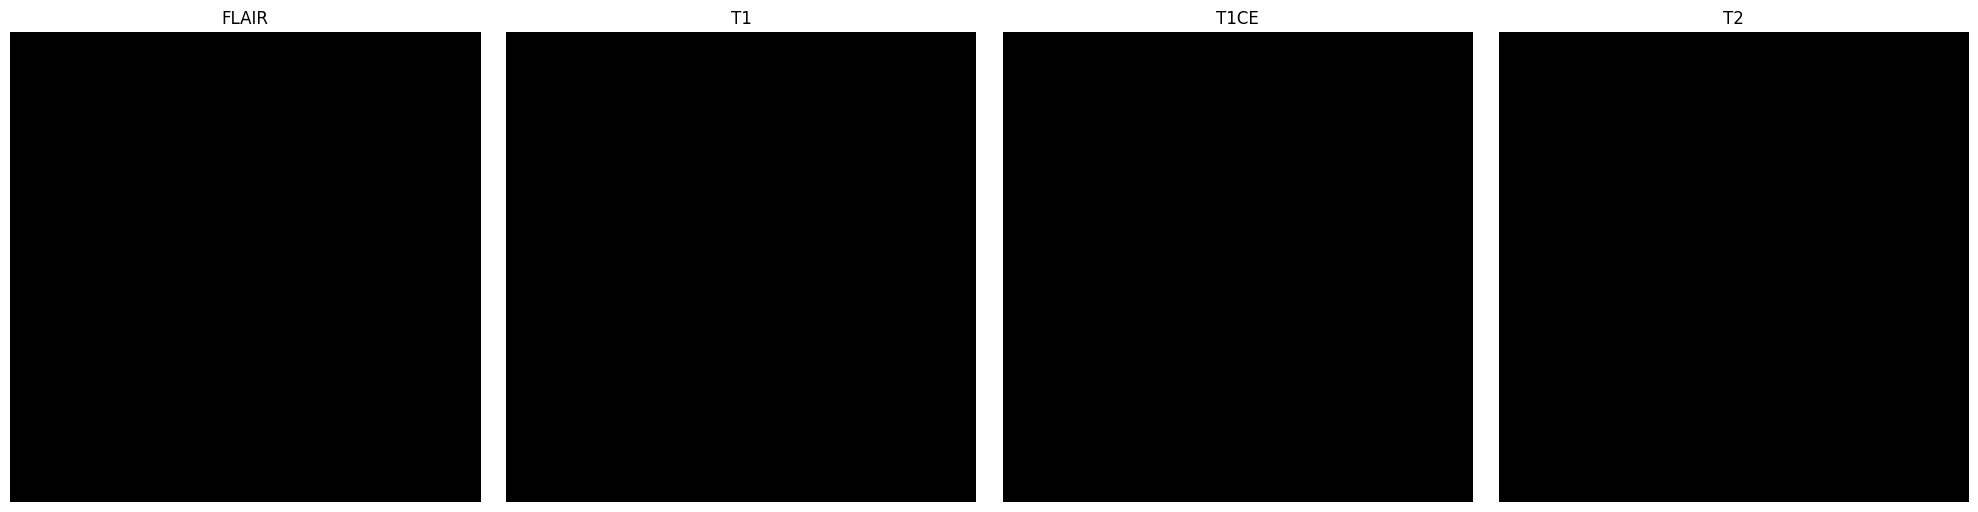

In [21]:
fig, ax = plt.subplots(1,4, figsize=(20,5))

titles = ["FLAIR","T1","T1CE","T2"]

for i in range(4):
    ax[i].imshow(image[:,:,i], cmap="gray")
    ax[i].set_title(titles[i])
    ax[i].axis("off")

plt.tight_layout()
plt.show()


# Visualize Tumor Masks

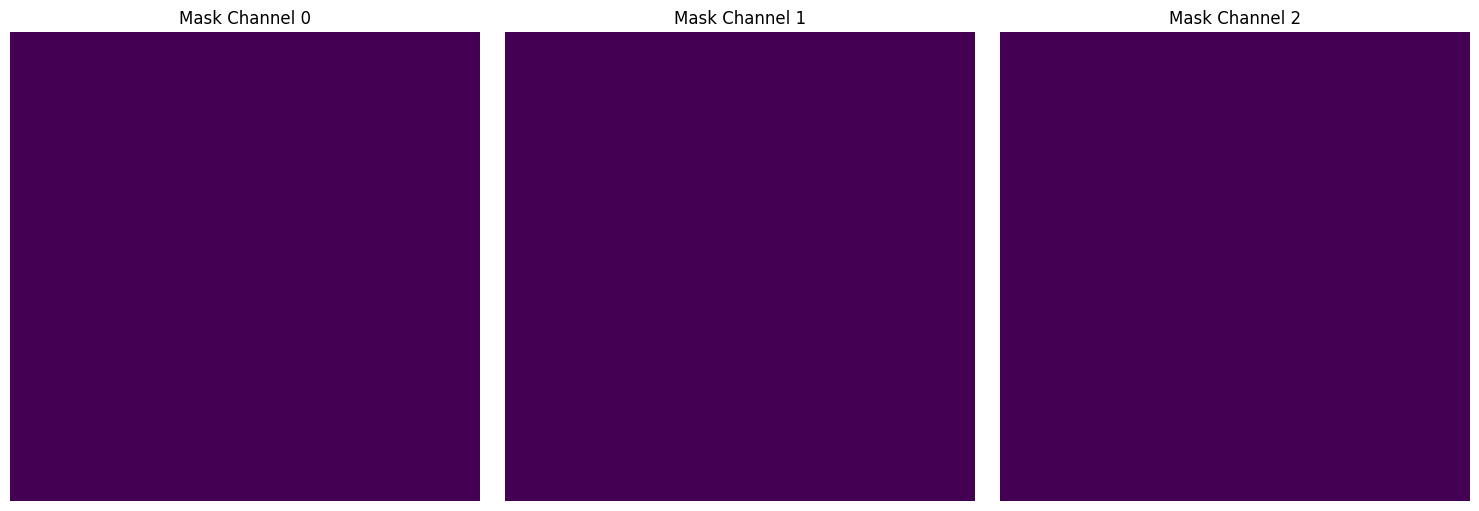

In [22]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

for i in range(3):
    ax[i].imshow(mask[:,:,i])
    ax[i].set_title(f"Mask Channel {i}")
    ax[i].axis("off")

plt.tight_layout()
plt.show()


# MRI + Tumor Overlay


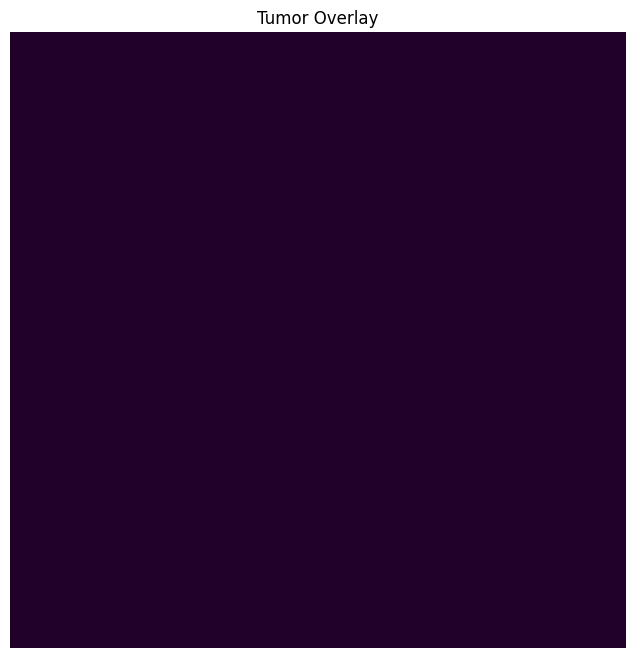

In [23]:
plt.figure(figsize=(8,8))

plt.imshow(image[:,:,0], cmap="gray")
plt.imshow(mask[:,:,0], alpha=0.5)

plt.title("Tumor Overlay")
plt.axis("off")

plt.show()


# Tumor Pixel Statistics

In [24]:
import numpy as np
from tqdm import tqdm

sample_files = files[:1000]   # pehle 1000 samples analyze karenge

tumor_pixels = []

for file in tqdm(sample_files):
    with h5py.File(file, "r") as f:
        mask = f["mask"][:]
        tumor_area = np.sum(mask > 0)
        tumor_pixels.append(tumor_area)

print("Min Tumor Pixels :", np.min(tumor_pixels))
print("Max Tumor Pixels :", np.max(tumor_pixels))
print("Mean Tumor Pixels:", np.mean(tumor_pixels))


100%|██████████| 1000/1000 [00:11<00:00, 83.86it/s]

Min Tumor Pixels : 0
Max Tumor Pixels : 3602
Mean Tumor Pixels: 518.496


# Tumor Area Distribution

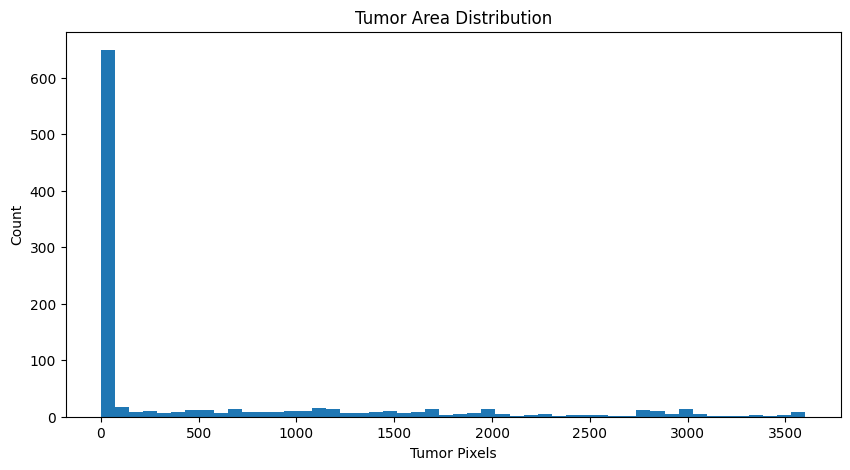

In [25]:
plt.figure(figsize=(10,5))

plt.hist(tumor_pixels, bins=50)

plt.title("Tumor Area Distribution")
plt.xlabel("Tumor Pixels")
plt.ylabel("Count")

plt.show()


# Empty vs Tumor Images

In [26]:
empty = 0
tumor = 0

for area in tumor_pixels:
    if area == 0:
        empty += 1
    else:
        tumor += 1

print("Empty Images :", empty)
print("Tumor Images :", tumor)


Empty Images : 612
Tumor Images : 388


# Class Distribution Graph

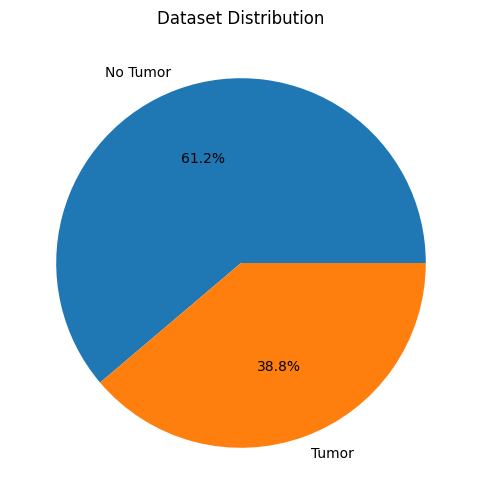

In [27]:
plt.figure(figsize=(6,6))

plt.pie(
    [empty, tumor],
    labels=["No Tumor","Tumor"],
    autopct="%1.1f%%"
)

plt.title("Dataset Distribution")

plt.show()


# Random MRI Samples

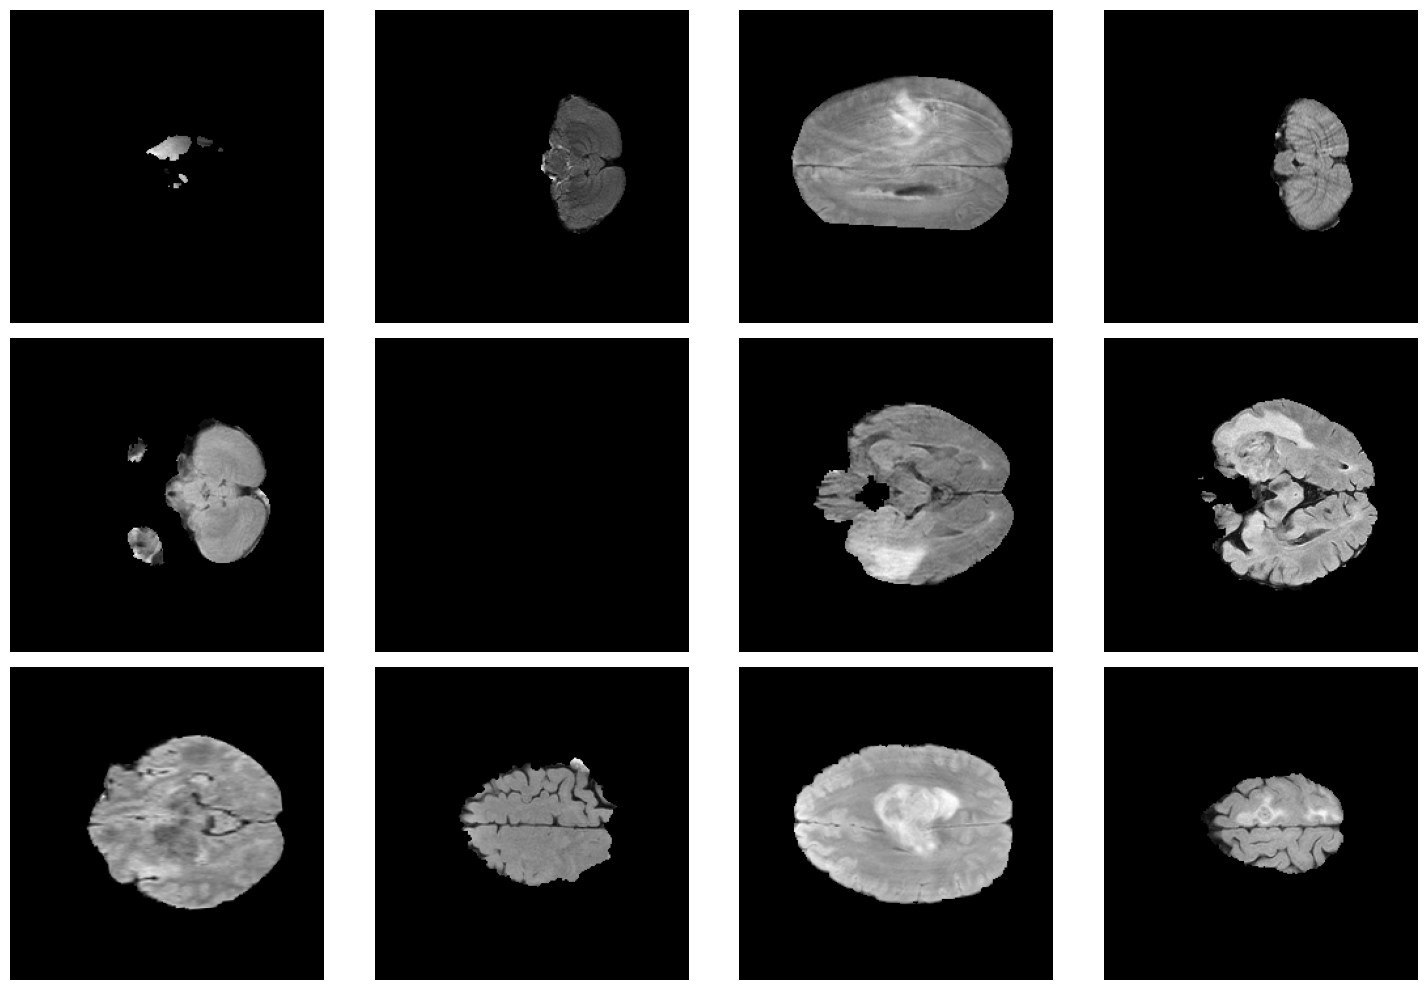

In [28]:
fig, ax = plt.subplots(3,4, figsize=(15,10))

for i in range(12):
    file = random.choice(files)
    with h5py.File(file, "r") as f:
        image_s = f["image"][:]

    r = i//4
    c = i%4
    ax[r,c].imshow(image_s[:,:,0], cmap="gray")
    ax[r,c].axis("off")

plt.tight_layout()
plt.show()


# Random Tumor Samples

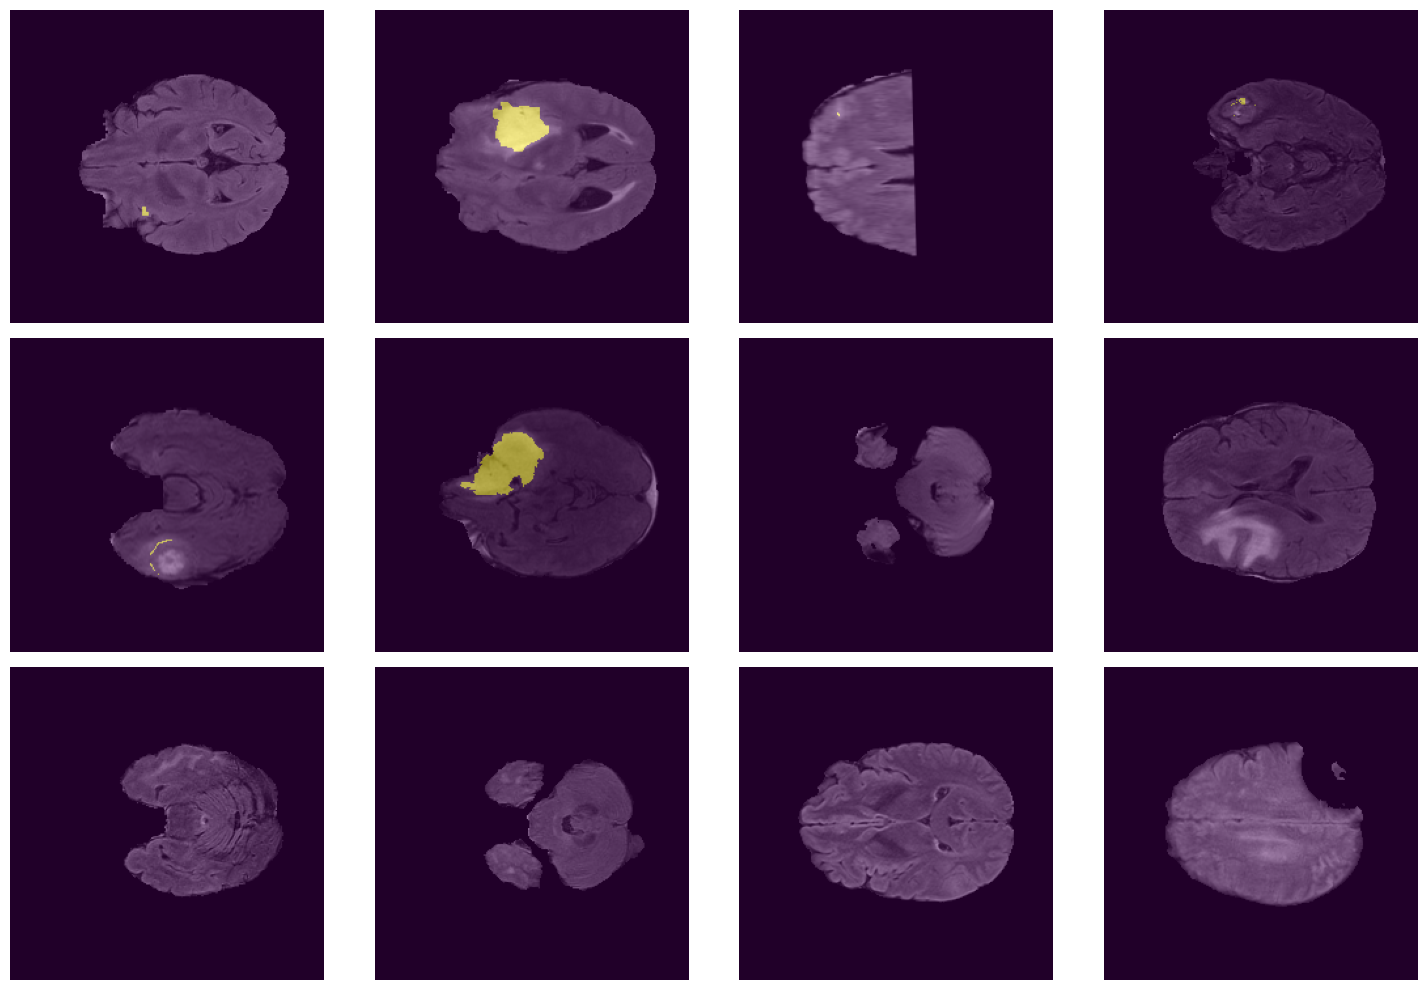

In [29]:
fig, ax = plt.subplots(3,4, figsize=(15,10))

count = 0

while count < 12:
    file = random.choice(files)
    with h5py.File(file, "r") as f:
        image_s = f["image"][:]
        mask_s = f["mask"][:]

    if np.sum(mask_s) > 0:
        r = count//4
        c = count%4
        ax[r,c].imshow(image_s[:,:,0], cmap="gray")
        ax[r,c].imshow(mask_s[:,:,0], alpha=0.5)
        ax[r,c].axis("off")
        count += 1

plt.tight_layout()
plt.show()


# Pixel Intensity Histogram

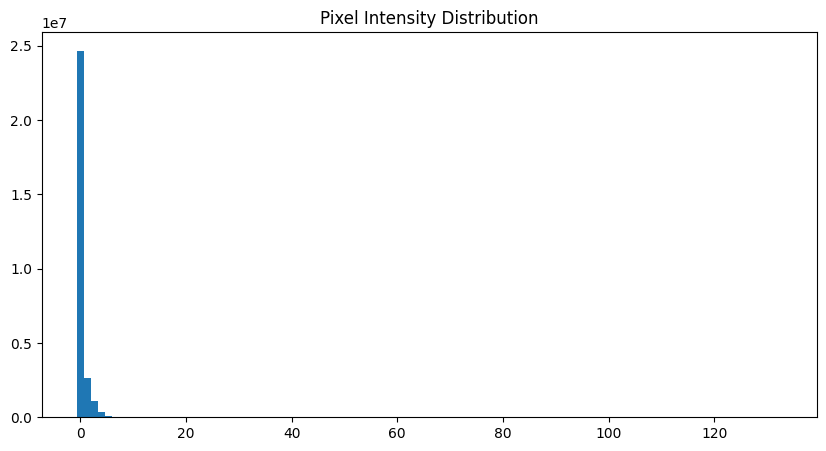

In [30]:
pixels = []

for file in files[:500]:
    with h5py.File(file, "r") as f:
        image_s = f["image"][:]
        pixels.extend(image_s[:,:,0].flatten())

plt.figure(figsize=(10,5))
plt.hist(pixels, bins=100)
plt.title("Pixel Intensity Distribution")
plt.show()


# Train Validation Test Split

In [31]:
from sklearn.model_selection import train_test_split

train_files, temp_files = train_test_split(
    files,
    test_size=0.30,
    random_state=42
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=42
)

print("Train :", len(train_files))
print("Val   :", len(val_files))
print("Test  :", len(test_files))


Train : 40036
Val   : 8579
Test  : 8580


# Remove Empty (No-Tumor) Slices

In [33]:
def filter_non_empty(file_list):
    valid_files = []
    for file in file_list:
        with h5py.File(file, "r") as f:
            mask = f["mask"][:]
        if np.sum(mask) > 0:
            valid_files.append(file)
    return valid_files

print("Filtering empty slices, ye ek baar chalega (kuch minute lag sakte hain)...")
train_files = filter_non_empty(train_files)
val_files   = filter_non_empty(val_files)
test_files  = filter_non_empty(test_files)

print("\nAfter filtering:")
print("Train :", len(train_files))
print("Val   :", len(val_files))
print("Test  :", len(test_files))


Filtering empty slices, ye ek baar chalega (kuch minute lag sakte hain)...

After filtering:
Train : 17074
Val   : 3721
Test  : 3627


# Data Generator (Production Ready)

In [73]:
IMG_SIZE = 64
BATCH_SIZE = 16   # 8 se 16 kiya — GPU better utilize hota hai, training fast hoti hai

def data_generator(file_list):
    while True:
        np.random.shuffle(file_list)

        for i in range(0, len(file_list), BATCH_SIZE):
            batch_files = file_list[i:i+BATCH_SIZE]

            images = []
            masks = []

            for file in batch_files:
                with h5py.File(file, "r") as f:
                    image = f["image"][:]
                    mask = f["mask"][:]

                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
                # FIX: nearest-neighbor resize, taaki binary mask blur na ho
                mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

                # FIX: max=0 (pure background slice) ke case me divide-by-zero NaN aata tha
                max_val = np.max(image)
                if max_val > 0:
                    image = image / max_val

                images.append(image)
                masks.append(mask)

            yield (
                np.array(images, dtype=np.float32),
                np.array(masks, dtype=np.float32)
            )


# Generator Test

In [74]:
train_gen = data_generator(train_files)

X, Y = next(train_gen)

print("Images :", X.shape)
print("Masks  :", Y.shape)
print("\nNaN check -> Images:", np.isnan(X).any(), "| Masks:", np.isnan(Y).any())
print("Image value range:", X.min(), "to", X.max())
print("Unique mask values (binary hone chahiye):", np.unique(Y))


Images : (16, 64, 64, 4)
Masks  : (16, 64, 64, 3)

NaN check -> Images: False | Masks: False
Image value range: -0.15161967 to 1.0
Unique mask values (binary hone chahiye): [0. 1.]


# Dice Coefficient


In [75]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


# Dice Loss

In [76]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)


# BCE + DIce loss

In [77]:
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)


# IoU Matrix

In [78]:
import tensorflow.keras.backend as K

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection

    return (intersection + smooth) / (union + smooth)


# Precision Matric

In [79]:
def precision_m(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision


# Recall Matric

In [80]:
def recall_m(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall


# F1 Score

In [81]:
def f1_score(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)

    return (2 * precision * recall) / (precision + recall + K.epsilon())


# Conv Block

In [82]:
from tensorflow.keras.layers import *

def conv_block(x, filters):
    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x


# Encoder Block

In [83]:
def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = MaxPooling2D((2,2))(c)
    p = Dropout(0.2)(p)
    return c, p


# Decoder Block

In [84]:
def decoder_block(x, skip, filters):
    x = Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = concatenate([x, skip])
    x = Dropout(0.2)(x)
    x = conv_block(x, filters)
    return x


# Improved U-net

In [85]:
from tensorflow.keras.models import Model

def build_unet():
    inputs = Input((IMG_SIZE, IMG_SIZE, 4))

    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)

    b1 = conv_block(p4, 512)

    d1 = decoder_block(b1, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)

    outputs = Conv2D(3, 1, activation="sigmoid")(d4)

    model = Model(inputs, outputs)
    return model


# Build Model

In [86]:
model = build_unet()

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 4) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 64, 64,    │      1,184 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 64, 64,    │      9,248 │ activation_36[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 32, 32,    │          0 │ activation_37[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 32, 32,    │          0 │ max_pooling2d_8[… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 32, 32,    │     18,496 │ dropout_16[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 32, 32,    │     36,928 │ activation_38[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_39       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 16, 16,    │          0 │ activation_39[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 16, 16,    │          0 │ max_pooling2d_9[

 Total params: 7,772,227 (29.65 MB)

 Trainable params: 7,766,339 (29.63 MB)

 Non-trainable params: 5,888 (23.00 KB)

# Compile Model

In [87]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[
        "accuracy",
        dice_coef,
        iou_score,
        precision_m,
        recall_m,
        f1_score
    ]
)


# Callbacks

In [88]:
from tensorflow.keras.callbacks import *

callbacks = [
    ModelCheckpoint(
        "best_model.keras",
        monitor="val_dice_coef",
        save_best_only=True,
        mode="max"
    ),

    EarlyStopping(
        monitor="val_dice_coef",
        patience=5,
        mode="max",
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    ),

    # FIX: agar phir bhi kabhi NaN aaye, training yahin rok do (time bachega)
    TerminateOnNaN()
]


# Create Generators

In [89]:
train_gen = data_generator(train_files)
val_gen = data_generator(val_files)
test_gen = data_generator(test_files)


# Training

In [92]:
EPOCHS = 10
STEPS_PER_EPOCH = min(300, len(train_files)//BATCH_SIZE)
VALIDATION_STEPS = min(60, len(val_files)//BATCH_SIZE)

print("Steps per epoch:", STEPS_PER_EPOCH)
print("Validation steps:", VALIDATION_STEPS)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks
)


Steps per epoch: 300
Validation steps: 60
Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 113s 377ms/step - accuracy: 0.9746 - dice_coef: 0.0752 - f1_score: 0.5178 - iou_score: 0.0392 - loss: 1.1112 - precision_m: 0.3893 - recall_m: 0.7849 - val_accuracy: 0.9778 - val_dice_coef: 0.0878 - val_f1_score: 0.5544 - val_iou_score: 0.0460 - val_loss: 1.0686 - val_precision_m: 0.4263 - val_recall_m: 0.7973 - learning_rate: 1.0000e-04
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 129s 433ms/step - accuracy: 0.9738 - dice_coef: 0.1085 - f1_score: 0.5550 - iou_score: 0.0575 - loss: 1.0169 - precision_m: 0.4252 - recall_m: 0.8081 - val_accuracy: 0.9794 - val_dice_coef: 0.1211 - val_f1_score: 0.5909 - val_iou_score: 0.0646 - val_loss: 0.9854 - val_precision_m: 0.4782 - val_recall_m: 0.7772 - learning_rate: 1.0000e-04
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 114s 380ms/step - accuracy: 0.9734 - dice_coef: 0.1620 - f1_score: 0.5833 - iou_score: 0.0885 - loss: 0.9213 - precision_m: 0.4540 - recall_m: 0.8244 - val_ac

# Training Curves

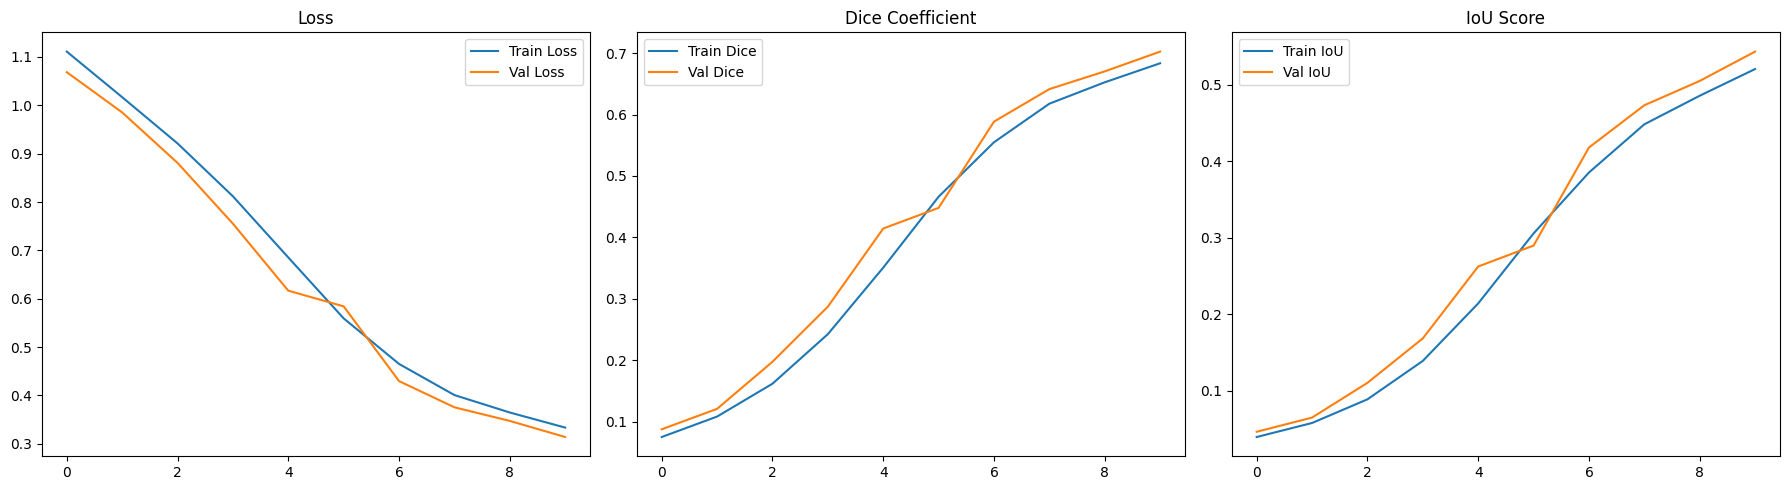

In [93]:
fig, axs = plt.subplots(1, 3, figsize=(18,5))

axs[0].plot(history.history['loss'], label='Train Loss')
axs[0].plot(history.history['val_loss'], label='Val Loss')
axs[0].set_title("Loss"); axs[0].legend()

axs[1].plot(history.history['dice_coef'], label='Train Dice')
axs[1].plot(history.history['val_dice_coef'], label='Val Dice')
axs[1].set_title("Dice Coefficient"); axs[1].legend()

axs[2].plot(history.history['iou_score'], label='Train IoU')
axs[2].plot(history.history['val_iou_score'], label='Val IoU')
axs[2].set_title("IoU Score"); axs[2].legend()

plt.tight_layout()
plt.show()


# Evaluate on Test Set

In [94]:
test_steps = min(60, len(test_files)//BATCH_SIZE)
results = model.evaluate(test_gen, steps=test_steps, verbose=1)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")


60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 306ms/step - accuracy: 0.9735 - dice_coef: 0.7146 - f1_score: 0.7638 - iou_score: 0.5575 - loss: 0.3006 - precision_m: 0.7572 - recall_m: 0.7714
loss: 0.3006
compile_metrics: 0.9735


# Visualize Predictions (Original vs True Mask vs Predicted Mask)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


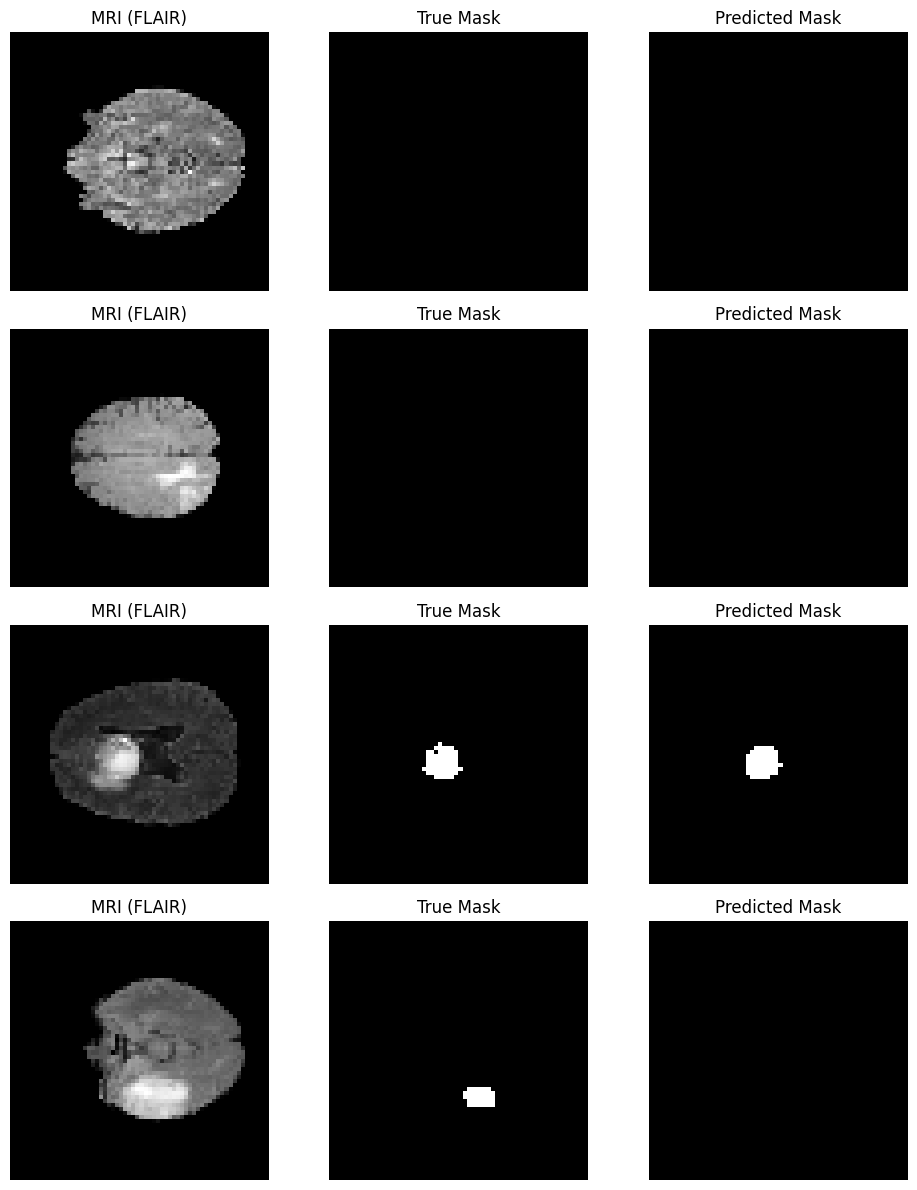

In [95]:
X_sample, Y_sample = next(test_gen)
preds = model.predict(X_sample)

n_show = 4
fig, axs = plt.subplots(n_show, 3, figsize=(10, n_show*3))

for i in range(n_show):
    axs[i,0].imshow(X_sample[i,:,:,0], cmap="gray")
    axs[i,0].set_title("MRI (FLAIR)")
    axs[i,0].axis("off")

    axs[i,1].imshow(Y_sample[i,:,:,0], cmap="gray")
    axs[i,1].set_title("True Mask")
    axs[i,1].axis("off")

    axs[i,2].imshow(preds[i,:,:,0] > 0.5, cmap="gray")
    axs[i,2].set_title("Predicted Mask")
    axs[i,2].axis("off")

plt.tight_layout()
plt.show()


# Accuracy Graph

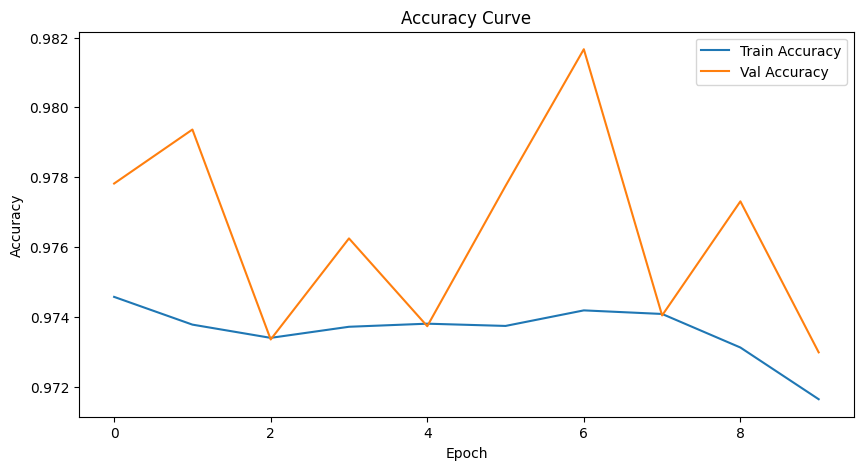

In [96]:
plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


# Loss Graph

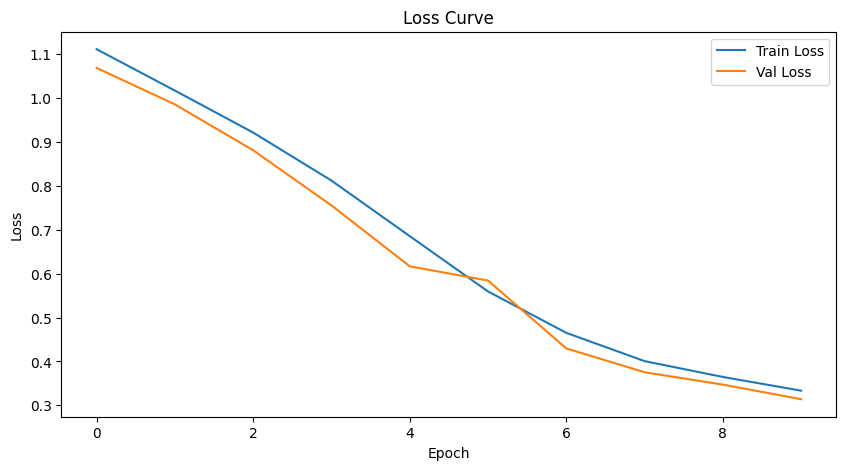

In [97]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


# Dice score

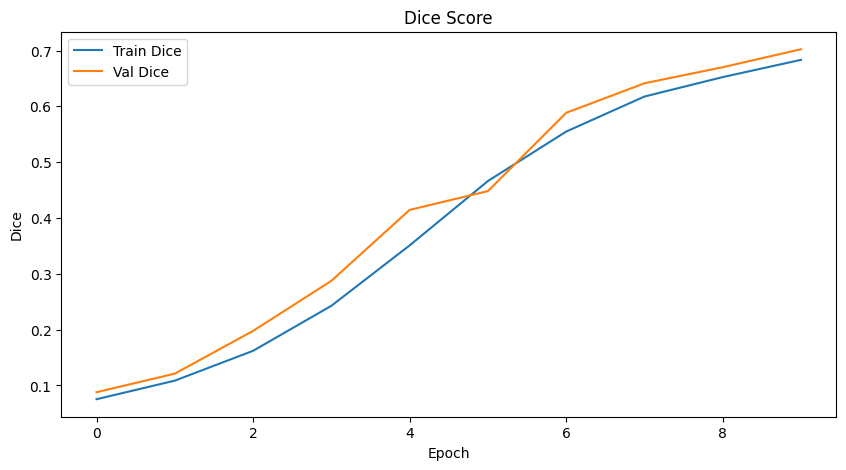

In [98]:
plt.figure(figsize=(10,5))

plt.plot(history.history["dice_coef"], label="Train Dice")
plt.plot(history.history["val_dice_coef"], label="Val Dice")

plt.title("Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()

plt.show()


# Precision Recall F1

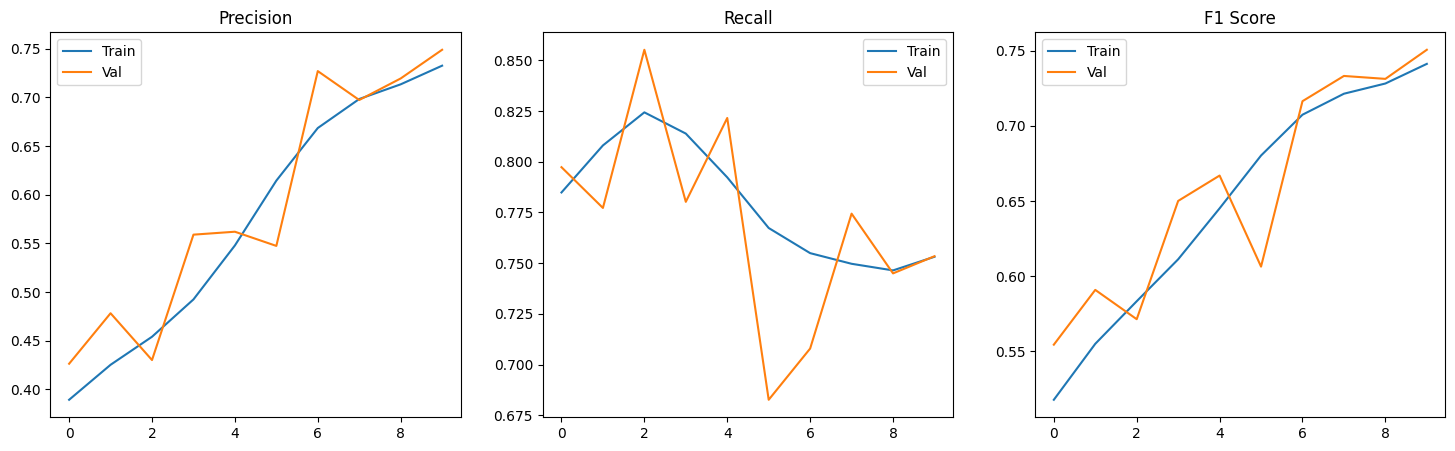

In [99]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

ax[0].plot(history.history["precision_m"], label="Train")
ax[0].plot(history.history["val_precision_m"], label="Val")
ax[0].set_title("Precision")
ax[0].legend()

ax[1].plot(history.history["recall_m"], label="Train")
ax[1].plot(history.history["val_recall_m"], label="Val")
ax[1].set_title("Recall")
ax[1].legend()

ax[2].plot(history.history["f1_score"], label="Train")
ax[2].plot(history.history["val_f1_score"], label="Val")
ax[2].set_title("F1 Score")
ax[2].legend()

plt.show()


# Load Best Model

In [100]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "best_model.keras",
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coef": dice_coef,
        "iou_score": iou_score,
        "precision_m": precision_m,
        "recall_m": recall_m,
        "f1_score": f1_score
    }
)


# Test Evaluation

In [101]:
results = best_model.evaluate(

    test_gen,

    steps=200
)

print(results)

200/200 ━━━━━━━━━━━━━━━━━━━━ 66s 315ms/step - accuracy: 0.9730 - dice_coef: 0.7093 - f1_score: 0.7588 - iou_score: 0.5510 - loss: 0.3064 - precision_m: 0.7555 - recall_m: 0.7630
[0.30638325214385986, 0.9729564785957336, 0.7093293070793152, 0.5510252118110657, 0.7554846405982971, 0.7629568576812744, 0.7587977051734924]


# Prediction


In [102]:
X_test, Y_test = next(test_gen)

pred = best_model.predict(X_test)

print("X_test Shape :", X_test.shape)
print("Y_test Shape :", Y_test.shape)
print("Prediction Shape :", pred.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
X_test Shape : (16, 64, 64, 4)
Y_test Shape : (16, 64, 64, 3)
Prediction Shape : (16, 64, 64, 3)


# Threashold

In [103]:
pred_mask = (pred > 0.5).astype(np.uint8)

print("Pred Mask Shape :", pred_mask.shape)


Pred Mask Shape : (16, 64, 64, 3)


# Single prediction 

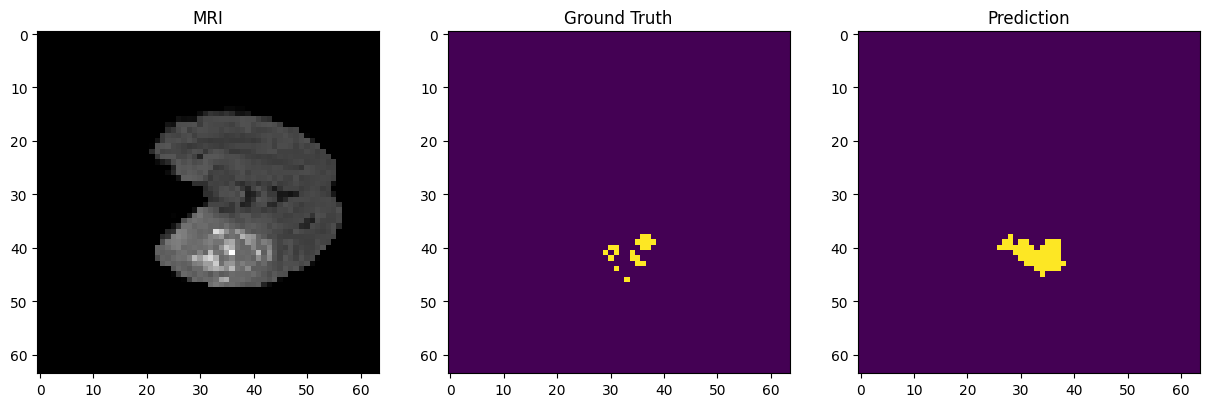

In [104]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(X_test[0][:,:,0], cmap="gray")
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(Y_test[0][:,:,0])
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_mask[0][:,:,0])
plt.title("Prediction")

plt.show()


# Overall Prediction

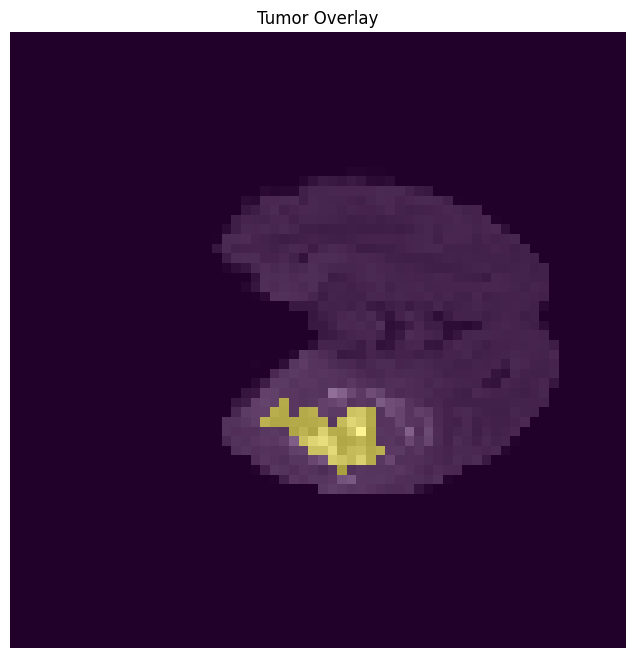

In [105]:
plt.figure(figsize=(8,8))

plt.imshow(X_test[0][:,:,0], cmap="gray")
plt.imshow(pred_mask[0][:,:,0], alpha=0.5)

plt.title("Tumor Overlay")
plt.axis("off")

plt.show()


# Multiple Prediction

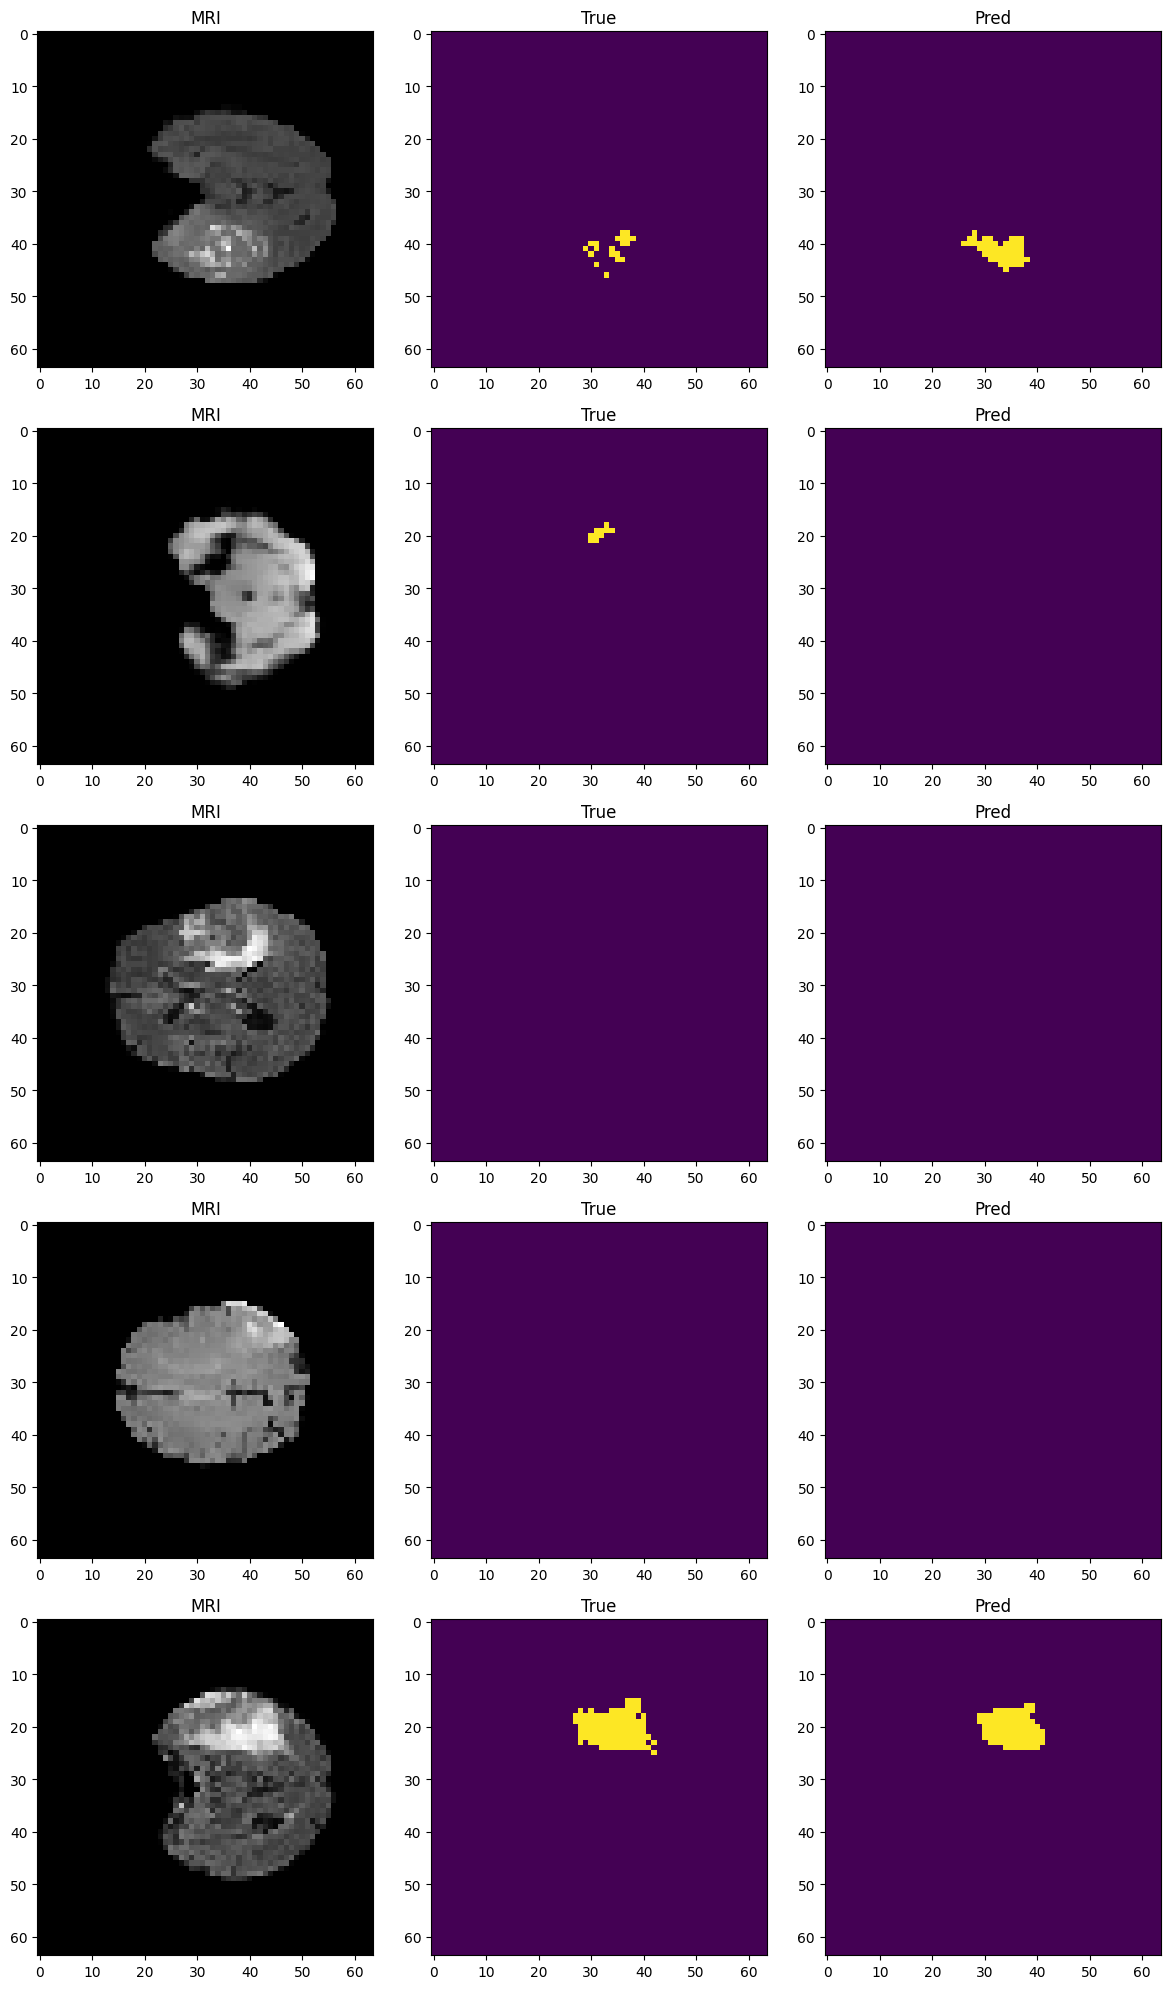

In [106]:
fig, ax = plt.subplots(5, 3, figsize=(12,20))

for i in range(5):
    ax[i,0].imshow(X_test[i][:,:,0], cmap="gray")
    ax[i,0].set_title("MRI")

    ax[i,1].imshow(Y_test[i][:,:,0])
    ax[i,1].set_title("True")

    ax[i,2].imshow(pred_mask[i][:,:,0])
    ax[i,2].set_title("Pred")

plt.tight_layout()
plt.show()


# confusion Matrix

In [107]:
from sklearn.metrics import confusion_matrix

y_true = (Y_test.flatten() > 0.5).astype(int)
y_pred = pred_mask.flatten().astype(int)

cm = confusion_matrix(y_true, y_pred)
print(cm)


[[195044    336]
 [   338    890]]


# Visual matrix

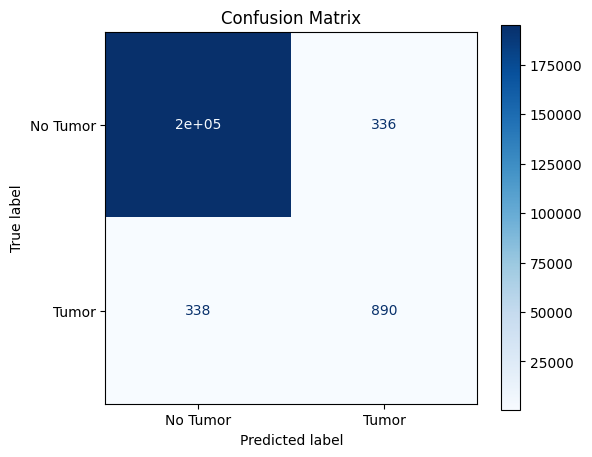

In [108]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Tumor","Tumor"])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# Clssification Reprt

In [109]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["No Tumor","Tumor"]))


              precision    recall  f1-score   support

    No Tumor       1.00      1.00      1.00    195380
       Tumor       0.73      0.72      0.73      1228

    accuracy                           1.00    196608
   macro avg       0.86      0.86      0.86    196608
weighted avg       1.00      1.00      1.00    196608



# Model save by Keras

In [110]:
MODEL_PATH = "brain_tumor_unet.keras"

model.save(MODEL_PATH)

print(f"✅ Model saved successfully at: {MODEL_PATH}")

✅ Model saved successfully at: brain_tumor_unet.keras


# Load model

In [111]:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    "brain_tumor_unet.keras",
    compile=False
)

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [112]:
pred = loaded_model.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


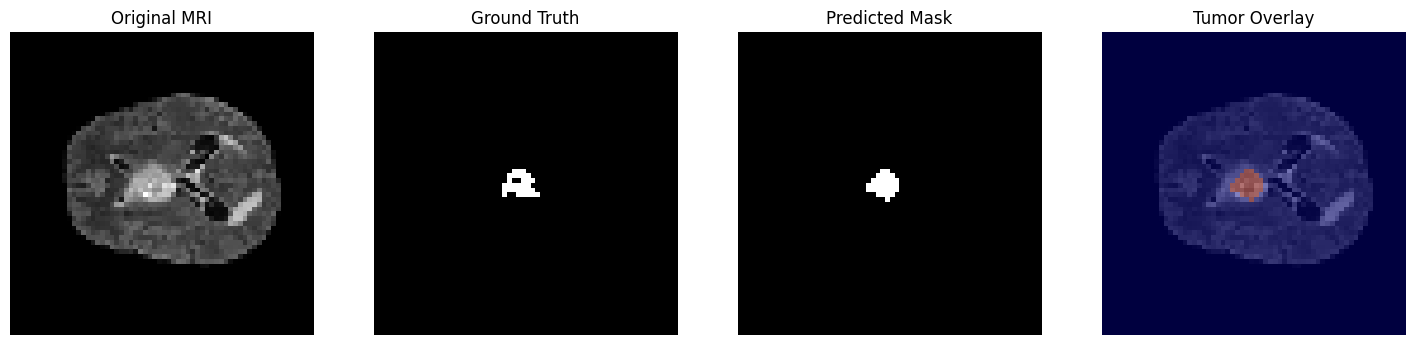

In [128]:
import numpy as np
import matplotlib.pyplot as plt

# Random test sample
idx = np.random.randint(0, len(X_test))

# Image aur Ground Truth
image = X_test[idx]
true_mask = Y_test[idx]

# Prediction
pred = loaded_model.predict(np.expand_dims(image, axis=0), verbose=0)
pred_mask = (pred[0] > 0.5).astype(np.uint8)

# Plot
plt.figure(figsize=(18,5))

# Original MRI
plt.subplot(1,4,1)
plt.imshow(image[:,:,0], cmap="gray")
plt.title("Original MRI")
plt.axis("off")

# Ground Truth
plt.subplot(1,4,2)
plt.imshow(true_mask[:,:,0], cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

# Predicted Mask
plt.subplot(1,4,3)
plt.imshow(pred_mask[:,:,0], cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

# Overlay
plt.subplot(1,4,4)
plt.imshow(image[:,:,0], cmap="gray")
plt.imshow(pred_mask[:,:,0], cmap="jet", alpha=0.5)
plt.title("Tumor Overlay")
plt.axis("off")

plt.show()

In [129]:
import numpy as np

true_pixels = np.sum(true_mask > 0)
pred_pixels = np.sum(pred_mask > 0)

print("Ground Truth Tumor Pixels :", true_pixels)
print("Predicted Tumor Pixels    :", pred_pixels)

Ground Truth Tumor Pixels : 68
Predicted Tumor Pixels    : 90


In [130]:
coords = np.argwhere(pred_mask[:,:,0] > 0)

if len(coords) > 0:
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    print(f"Bounding Box:")
    print(f"Top-Left     : ({x_min}, {y_min})")
    print(f"Bottom-Right : ({x_max}, {y_max})")
    print(f"Width        : {x_max - x_min + 1} pixels")
    print(f"Height       : {y_max - y_min + 1} pixels")
else:
    print("No tumor detected.")

Bounding Box:
Top-Left     : (27, 29)
Bottom-Right : (33, 35)
Width        : 7 pixels
Height       : 7 pixels
